***** UNIT 7 CODE *****

The goal of this code is to apply text data visualization as an emerging technology in NLP to this project.

In [141]:
import numpy as np
import pandas as pd

In [142]:
path = '/content/drive/My Drive/CIS617_TextAnalytics/TextAnalyticsCode_FordKCAP'
reviews_df = pd.read_csv(path+'/reviews.csv')
#reviews_df.head(3)

In [143]:
import re
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import bigrams
import nltk
#nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [144]:
text = str(reviews_df["snippet"])

# Preprocessing
mystopwords = ['get','go','back','ford','dont','like','still','bought','2018','way','f150','completel','lov','say','name','across','snippet','make','today','object','dtype','e','0','1','3','2','4','193','194','195','196','197','198'] #Common words to ignore

text = re.sub(r'\W+', ' ', text.lower())
tokens = word_tokenize(text)
tokens = [word for word in tokens if word not in stopwords.words('english')+mystopwords]

In [145]:
# Generate bigrams
bigram_list = list(bigrams(tokens))
bigram_counts = Counter(bigram_list)

In [146]:
# Create the bigram network
G = nx.Graph()
for (word1, word2), freq in bigram_counts.items():
    G.add_edge(word1, word2, weight=freq)

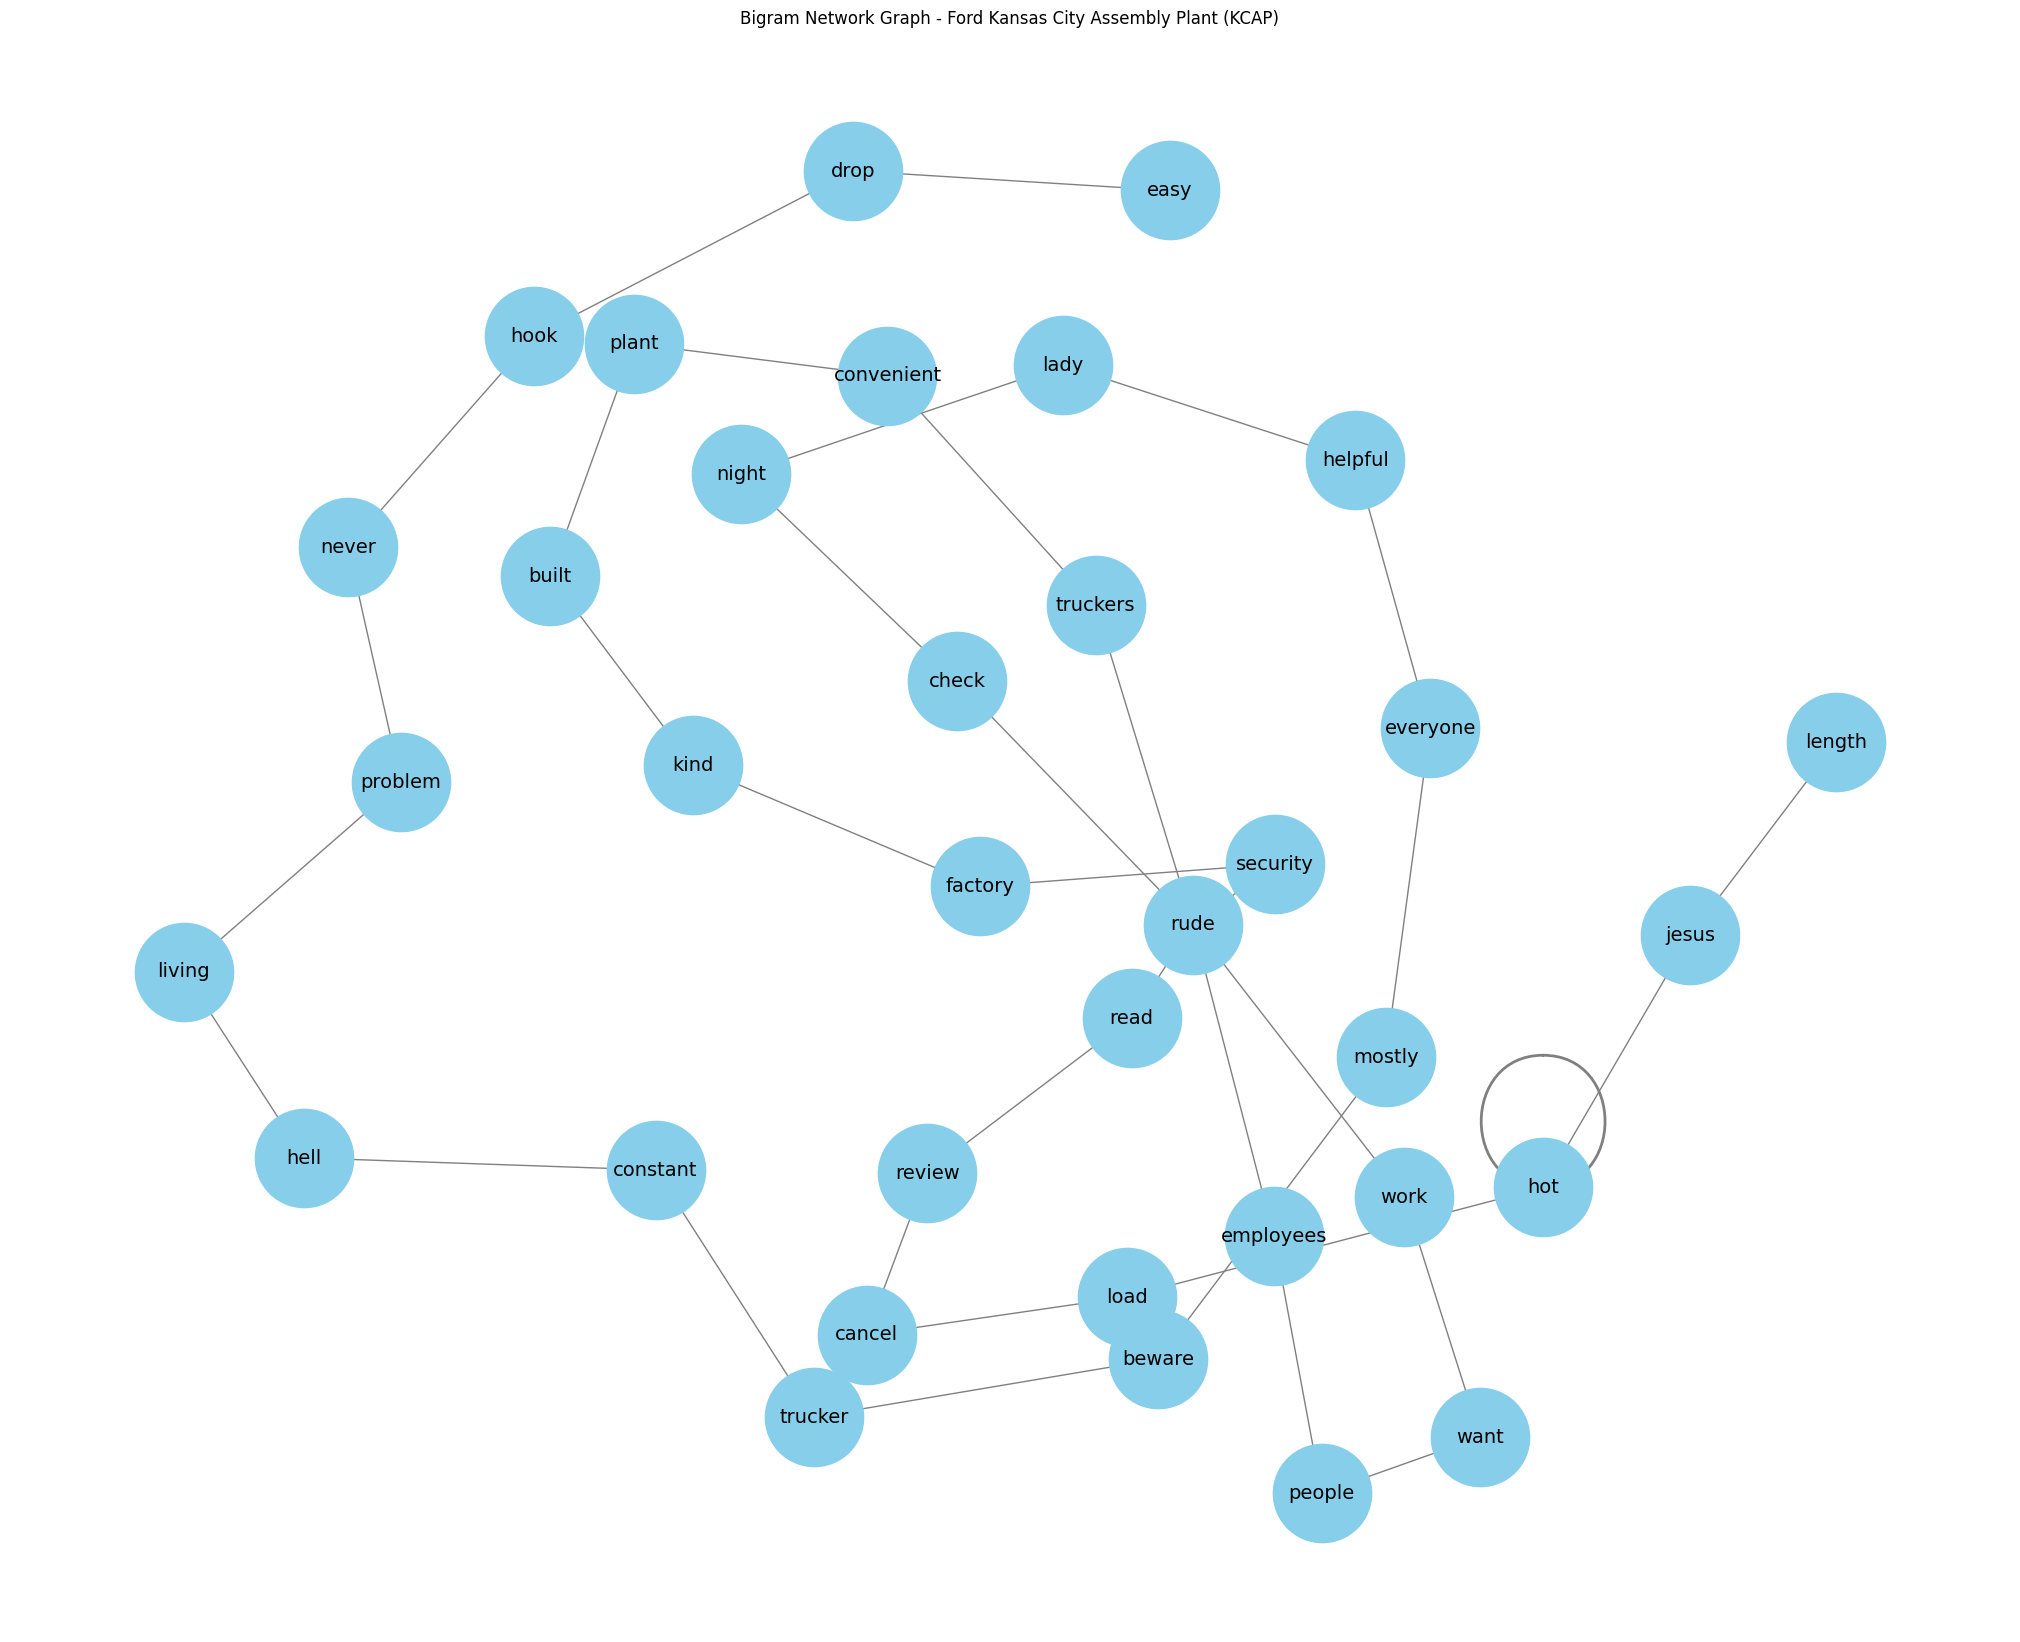

In [147]:
# Draw the network
plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, k=0.5)
edges = G.edges(data=True)
weights = [edge[2]['weight'] for edge in edges]

nx.draw(G, pos, with_labels=True, node_size=5000, node_color='skyblue', edge_color='gray', width=weights, font_size=14)
plt.title('Bigram Network Graph - Ford Kansas City Assembly Plant (KCAP)')
plt.show()

The cells above construct a Bigram Network graph to reveal how words and entities connect within a dataset. In this diagram, nodes represent individual words, concepts, or named entities, while edges illustrate the relationships or interactions between them.

The resulting visualization displays the most common two-word phrase combinations found throughout the Ford KCAP review data. The graph highlights paired terms that effectively preserve the reviewer’s meaning and context. These findings reveal a few noticeable themes related to employee interactions, working conditions, trucker experiences, and overall workplace sentiment.

One of the most prominent clusters centers around "rude", "security", "employees", "work", "people", "everyone", and "mostly". This likely suggests that many reviews focused on staff behavior and personal interactions. The repeated connection to rude is especially important because it may indicate recurring complaints about customer service, communication style, or treatment of visitors and drivers. Employee interactions have a strong potential to influence public perception - making this finding a key insight for management.

Another visible cluster highlights "hot", "work", "length", and "jesus". This seems to highlight potential concerns about uncomfortable working conditions, physically demanding labor, or long shifts. The emotional term “jesus” is often associated with stressful conditions as it likely reflects frustration or disbelief. If multiple reviewers mention heat or difficult work environments, this could indicate concerns about employee comfort, safety, or morale.
